In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/content/ncr_ride_bookings.csv')

In [3]:
df.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,...,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI


In [5]:
df.shape

(150000, 21)

In [7]:
df.columns

Index(['Date', 'Time', 'Booking ID', 'Booking Status', 'Customer ID',
       'Vehicle Type', 'Pickup Location', 'Drop Location', 'Avg VTAT',
       'Avg CTAT', 'Cancelled Rides by Customer',
       'Reason for cancelling by Customer', 'Cancelled Rides by Driver',
       'Driver Cancellation Reason', 'Incomplete Rides',
       'Incomplete Rides Reason', 'Booking Value', 'Ride Distance',
       'Driver Ratings', 'Customer Rating', 'Payment Method'],
      dtype='object')

In [8]:
df.dtypes

,0
Date,object
Time,object
Booking ID,object
Booking Status,object
Customer ID,object
Vehicle Type,object
Pickup Location,object
Drop Location,object
Avg VTAT,float64
Avg CTAT,float64


In [18]:
df.isnull().sum()

,0
Date,0
Time,0
Booking ID,0
Booking Status,0
Customer ID,0
Vehicle Type,0
Pickup Location,0
Drop Location,0
Avg VTAT,10500
Avg CTAT,48000


In [19]:
missing_percent = (df.isnull().sum() / len(df)) * 100
print(missing_percent.sort_values(ascending=False))

Incomplete Rides                     94.0
Incomplete Rides Reason              94.0
Reason for cancelling by Customer    93.0
Cancelled Rides by Customer          93.0
Driver Cancellation Reason           82.0
Cancelled Rides by Driver            82.0
Driver Ratings                       38.0
Customer Rating                      38.0
Ride Distance                        32.0
Avg CTAT                             32.0
Payment Method                       32.0
Booking Value                        32.0
Avg VTAT                              7.0
Date                                  0.0
Time                                  0.0
Pickup Location                       0.0
Vehicle Type                          0.0
Customer ID                           0.0
Booking Status                        0.0
Booking ID                            0.0
Drop Location                         0.0
Day                                   0.0
Day_Type                              0.0
dtype: float64


In [20]:
df['Cancelled Rides by Customer'] = df['Cancelled Rides by Customer'].fillna(0)

df['Reason for cancelling by Customer'] = df['Reason for cancelling by Customer'].fillna('Not Cancelled')

In [22]:
# Cancelled Rides by Driver
df['Cancelled Rides by Driver'] = df['Cancelled Rides by Driver'].fillna(0)

df['Driver Cancellation Reason'] = df['Driver Cancellation Reason'].fillna('Not Cancelled')

In [23]:
# Incomplete Rides
df['Incomplete Rides'] = df['Incomplete Rides'].fillna(0)

df['Incomplete Rides Reason'] = df['Incomplete Rides Reason'].fillna('Ride Completed')

In [24]:
df[['Avg VTAT',
    'Avg CTAT',
    'Booking Value',
    'Ride Distance',
    'Driver Ratings',
    'Customer Rating']].isnull().sum()

,0
Avg VTAT,10500
Avg CTAT,48000
Booking Value,48000
Ride Distance,48000
Driver Ratings,57000
Customer Rating,57000


In [25]:
num_cols = ['Avg VTAT',
            'Avg CTAT',
            'Booking Value',
            'Ride Distance',
            'Driver Ratings',
            'Customer Rating']

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [26]:
df.isnull().sum()

,0
Date,0
Time,0
Booking ID,0
Booking Status,0
Customer ID,0
Vehicle Type,0
Pickup Location,0
Drop Location,0
Avg VTAT,0
Avg CTAT,0


In [27]:
df['Payment Method'].value_counts(dropna=False)

,count
Payment Method,
NaN,48000
UPI,45909
Cash,25367
Uber Wallet,12276
Credit Card,10209
Debit Card,8239


In [28]:
df['Payment Method'] = df['Payment Method'].fillna('Unknown')

In [29]:
df['Payment Method'].value_counts()

,count
Payment Method,
Unknown,48000
UPI,45909
Cash,25367
Uber Wallet,12276
Credit Card,10209
Debit Card,8239


In [30]:
df.isnull().sum().sort_values(ascending=False)

,0
Date,0
Time,0
Booking ID,0
Booking Status,0
Customer ID,0
Vehicle Type,0
Pickup Location,0
Drop Location,0
Avg VTAT,0
Avg CTAT,0


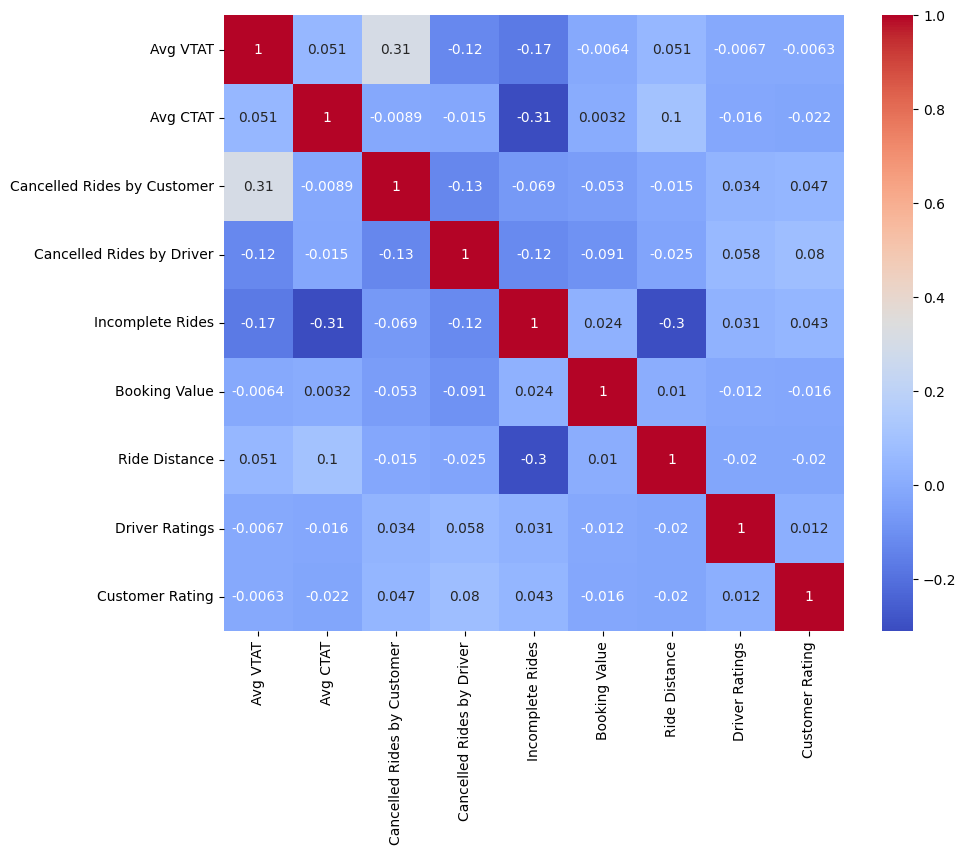

In [32]:
# correlation
numeric_df = df.select_dtypes(include=['int64', 'float64'])

corr = numeric_df.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

In [33]:
df['Date'] = pd.to_datetime(df['Date'])
df['Day'] = df['Date'].dt.day_name()

df['Day_Type'] = df['Day'].apply(
    lambda x: 'Weekend' if x in ['Saturday', 'Sunday'] else 'Weekday'
)

In [34]:
df.groupby('Day_Type')['Avg CTAT'].mean()

,Avg CTAT
Day_Type,
Weekday,29.011734
Weekend,29.102625


In [35]:
#Define hypotheses:

#Null Hypothesis (H0) ➜ No difference in ride durations ➜ Weekend = Weekday
# Alternative Hypothesis (H1) ➜ There is a difference

In [36]:
# T-test
from scipy.stats import ttest_ind

weekday = df[df['Day_Type'] == 'Weekday']['Avg CTAT']
weekend = df[df['Day_Type'] == 'Weekend']['Avg CTAT']

t_stat, p_value = ttest_ind(weekday, weekend, nan_policy='omit')

print("P-value:", p_value)

P-value: 0.03024038706725678


In [37]:
# Interpret Result
if p_value < 0.05:
    print("Ride durations differ significantly between weekdays and weekends.")
else:
    print("Ride durations differ significantly between weekdays and weekends.")

Ride durations differ significantly between weekdays and weekends.


<Axes: xlabel='Day_Type', ylabel='Avg CTAT'>

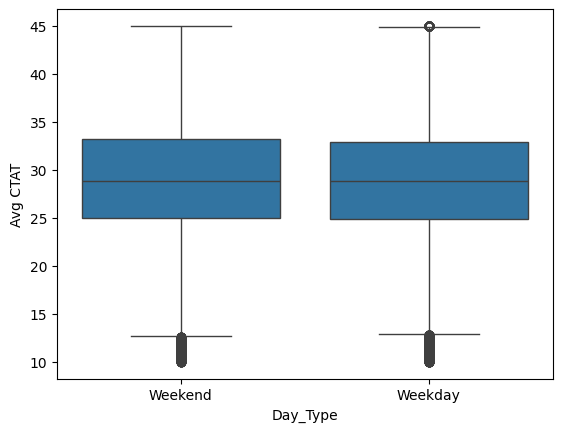

In [38]:
# shows differences in distribution.
sns.boxplot(x='Day_Type', y='Avg CTAT', data=df)

In [39]:
# Weekend rides are longer → more leisure travel
# Weekday rides shorter → work commute patterns